# Prediksi Student Performance Index dengan Linear Regression

**Nama:** Muhammad Rafa Enrico
**NIM:** 4.33.24.2.15
**Kelas:** TI-3C
**Mata Kuliah:** Pembelajaran Mesin

---

### Latar Belakang
Performa akademik siswa tidak hanya ditentukan oleh satu faktor. Lama waktu belajar, nilai yang pernah diperoleh sebelumnya, keikutsertaan dalam kegiatan di luar kelas, pola tidur, hingga seberapa sering siswa berlatih soal dapat ikut memengaruhi hasil belajarnya. Dengan memanfaatkan *machine learning*, hubungan antara faktor-faktor tersebut dan performa siswa dapat dipelajari langsung dari data, kemudian digunakan untuk memperkirakan performa siswa lain yang belum diketahui nilainya.

### Tujuan
1. Membangun model **Multiple Linear Regression** untuk memprediksi **Performance Index** siswa.
2. Mengetahui faktor mana yang paling berpengaruh terhadap Performance Index.
3. Mengevaluasi seberapa akurat model dalam melakukan prediksi.

### Dataset
Dataset *Student Performance* berisi 10.000 data siswa dengan 5 fitur dan 1 target:

| Kolom | Keterangan | Peran |
|---|---|---|
| Hours Studied | Jumlah jam belajar | Fitur (X) |
| Previous Scores | Nilai ujian sebelumnya | Fitur (X) |
| Extracurricular Activities | Ikut ekstrakurikuler (Yes/No) | Fitur (X) |
| Sleep Hours | Rata-rata jam tidur per hari | Fitur (X) |
| Sample Question Papers Practiced | Jumlah latihan soal yang dikerjakan | Fitur (X) |
| Performance Index | Indeks performa siswa (10–100) | Target (y) |

### Mengapa Linear Regression?
Nilai yang ingin diprediksi, yaitu Performance Index, berupa angka kontinu sehingga permasalahan ini termasuk **regresi**, bukan klasifikasi. Linear Regression dipilih sebagai metode utama karena sederhana, cepat dilatih, dan hasilnya mudah dipahami. Setiap fitur akan memiliki koefisien yang secara langsung menunjukkan seberapa besar dan ke arah mana fitur tersebut memengaruhi target, sehingga model tidak hanya bisa memprediksi tetapi juga bisa menjelaskan.

## 1. Import Library
Langkah pertama adalah memuat seluruh library yang akan digunakan selama proses analisis dan pemodelan:
- `pandas` dan `numpy` untuk membaca, mengolah, dan menghitung data.
- `matplotlib` dan `seaborn` untuk membuat visualisasi.
- `scikit-learn` untuk membagi data, membangun model Linear Regression, dan menghitung metrik evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load Dataset
Dataset dibaca dari file `Student_Performance.csv` dan disimpan ke dalam DataFrame agar mudah diolah. Lima baris pertama ditampilkan untuk mendapatkan gambaran awal mengenai isi dan format data.

In [2]:
# Membaca dataset
df = pd.read_csv('Student_Performance.csv')

# Menampilkan 5 baris pertama
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


**Interpretasi:** Data berhasil dibaca dengan baik, dan setiap baris mewakili satu siswa. Dari tampilan awal ini sudah terlihat bahwa kolom **Extracurricular Activities** masih berisi teks (*Yes*/*No*), sedangkan kolom lainnya sudah berupa angka. Hal ini menjadi catatan untuk tahap preprocessing nanti.

## 3. Pengecekan Data
Sebelum digunakan untuk melatih model, kualitas data perlu dipastikan terlebih dahulu. Data yang bermasalah, misalnya memiliki tipe data yang tidak sesuai, nilai kosong, atau baris ganda, dapat membuat model mempelajari pola yang keliru sehingga hasil prediksinya tidak dapat dipercaya. Oleh karena itu, pada tahap ini data diperiksa dari empat sisi: struktur, statistik, nilai kosong, dan duplikasi.

### 3.1 Struktur dan Tipe Data

In [3]:
# Cek nama kolom, tipe data, dan nilai null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


**Interpretasi:** Dataset terdiri dari **10.000 baris dan 6 kolom**. Lima kolom sudah bertipe numerik (`int64` dan `float64`), sedangkan **Extracurricular Activities** masih bertipe `object` atau teks. Karena Linear Regression hanya dapat memproses data numerik, kolom ini perlu diubah menjadi angka pada tahap preprocessing.

### 3.2 Statistik Deskriptif

In [4]:
# Cek mean, min, max, kuartil data numerik
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


**Interpretasi:** Ringkasan statistik menunjukkan rentang nilai setiap kolom sebagai berikut:
- **Hours Studied:** 1–9 jam (rata-rata ±5 jam)
- **Previous Scores:** 40–99 (rata-rata ±69,4)
- **Sleep Hours:** 4–9 jam (rata-rata ±6,5 jam)
- **Sample Question Papers Practiced:** 0–9 (rata-rata ±4,6)
- **Performance Index:** 10–100 (rata-rata ±55,2)

Seluruh nilai berada dalam rentang yang wajar dan tidak ditemukan nilai janggal seperti angka negatif, sehingga tidak diperlukan penanganan *outlier*. Satu hal yang perlu dicatat adalah skala antar fitur yang cukup berbeda. Previous Scores bernilai puluhan, sedangkan fitur lainnya hanya bernilai satuan. Perbedaan skala ini akan berpengaruh saat membaca koefisien model, karena koefisien yang kecil belum tentu berarti pengaruhnya kecil.

### 3.3 Pengecekan Missing Value

In [5]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


**Interpretasi:** Seluruh kolom bernilai 0, yang berarti **tidak ada data yang kosong**. Dengan demikian, data dapat langsung digunakan tanpa perlu proses pengisian maupun penghapusan nilai kosong.

### 3.4 Pengecekan dan Penghapusan Data Duplikat
Data duplikat adalah baris yang isinya sama persis dengan baris lain. Jika dibiarkan, data yang sama akan terhitung lebih dari sekali sehingga model menjadi bias. Selain itu, duplikat juga berisiko muncul di data latih dan data uji sekaligus, yang membuat hasil evaluasi terlihat lebih baik dari kenyataannya.

In [6]:
print("Jumlah duplikat:", df.duplicated().sum())
df = df.drop_duplicates()

Jumlah duplikat: 127


**Interpretasi:** Ditemukan **127 baris duplikat** yang kemudian dihapus, sehingga jumlah data berkurang dari 10.000 menjadi **9.873 baris**. Data inilah yang digunakan pada seluruh tahap selanjutnya.

## 4. Preprocessing (Label Encoding)
Seperti yang telah ditemukan pada tahap pengecekan data, kolom **Extracurricular Activities** masih berupa teks. Linear Regression bekerja dengan perhitungan matematis, sehingga seluruh input harus berbentuk angka. Karena kolom ini hanya memiliki dua kategori, cukup dilakukan *label encoding* menjadi nilai biner:
- `Yes` → **1** (ikut ekstrakurikuler)
- `No` → **0** (tidak ikut ekstrakurikuler)

In [7]:
# Mengubah 'Yes' menjadi 1 dan 'No' menjadi 0
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Cek kembali data setelah diubah
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


**Interpretasi:** Kolom Extracurricular Activities kini sudah bernilai 0 dan 1. Seluruh kolom sudah bertipe numerik, sehingga data siap dieksplorasi lebih lanjut dan digunakan untuk melatih model.

## 5. Exploratory Data Analysis (EDA)
Setelah data bersih, langkah berikutnya adalah memahami pola yang ada di dalam data sebelum model dibuat. Eksplorasi ini dilakukan dengan dua cara: melihat bagaimana sebaran nilai setiap variabel melalui histogram, lalu melihat seberapa kuat hubungan setiap fitur dengan target melalui correlation matrix. Hasil EDA ini nantinya menjadi dasar untuk memahami dan memvalidasi hasil model.

### 5.1 Histogram
Histogram digunakan untuk melihat sebaran nilai pada setiap kolom numerik. Kolom Extracurricular Activities tidak ditampilkan karena hanya berisi nilai 0 dan 1.

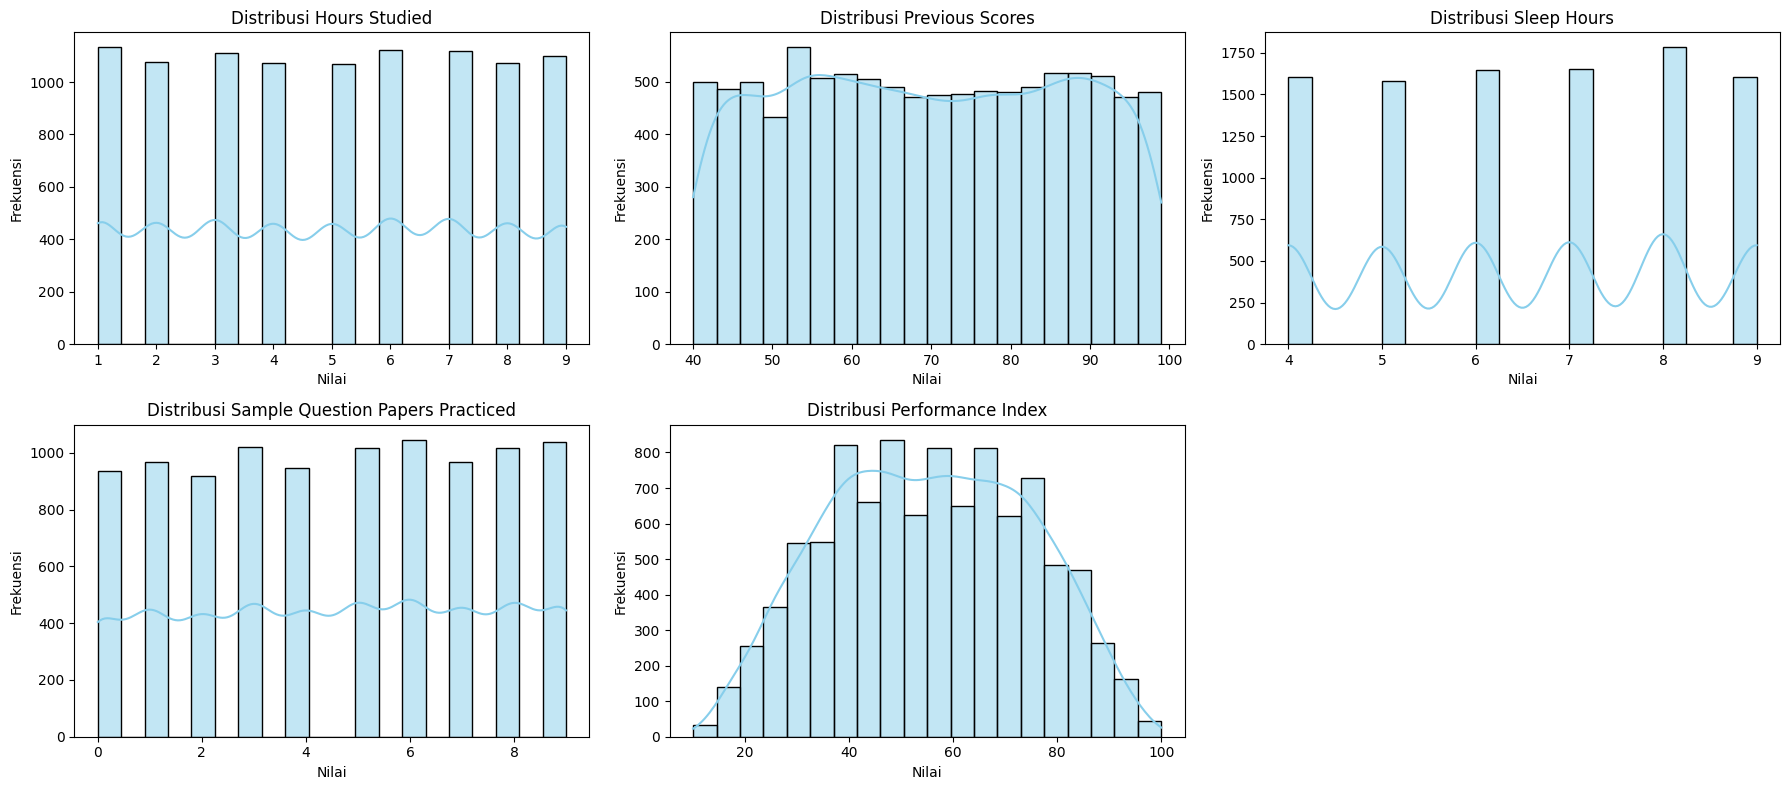

In [8]:
# Menampilkan histogram distribusi untuk semua kolom numerik
numerical_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                  'Sample Question Papers Practiced', 'Performance Index']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(f'Distribusi {column}')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

# Menyembunyikan subplot ke-6 yang kosong agar tampilan rapi
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Interpretasi:** Fitur **Hours Studied**, **Sleep Hours**, dan **Sample Question Papers Practiced** berupa bilangan bulat dengan jumlah data yang hampir sama pada setiap nilainya, sehingga sebarannya relatif merata (*uniform*). **Previous Scores** juga tersebar cukup merata di seluruh rentang 40–99.

Berbeda dengan fitur-fiturnya, **Performance Index** memiliki sebaran berbentuk menyerupai lonceng. Sebagian besar siswa memiliki nilai di kisaran 35–75, sedangkan siswa dengan nilai sangat rendah (di bawah 20) maupun sangat tinggi (di atas 90) jumlahnya sedikit. Tidak terlihat adanya ketimpangan atau *outlier* ekstrem, sehingga data layak digunakan untuk pemodelan.

### 5.2 Correlation Matrix
Heatmap korelasi digunakan untuk mengukur kekuatan hubungan linear antar variabel. Nilai korelasi berkisar antara −1 hingga 1:
- **Mendekati 1:** hubungan positif kuat (jika X naik, y ikut naik)
- **Mendekati −1:** hubungan negatif kuat (jika X naik, y turun)
- **Mendekati 0:** hampir tidak ada hubungan linear

Selain melihat hubungan fitur dengan target, heatmap ini juga digunakan untuk mengecek **multikolinearitas**, yaitu kondisi ketika antar fitur saling berkorelasi tinggi sehingga koefisien regresi menjadi tidak stabil.

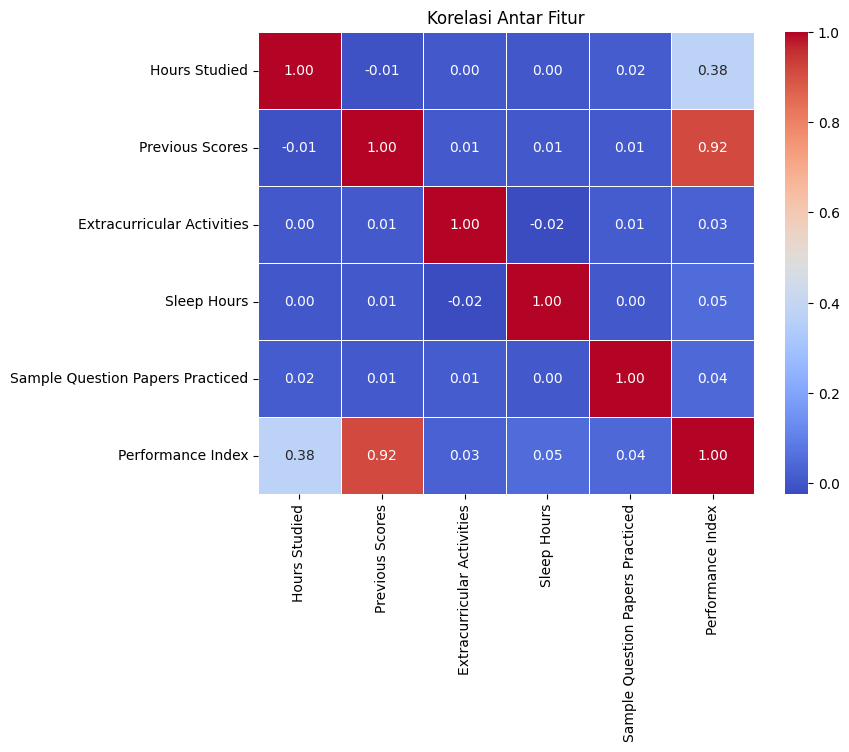

In [9]:
# Heatmap korelasi antar variabel
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Fitur')
plt.show()

**Interpretasi:** Korelasi setiap fitur terhadap Performance Index adalah sebagai berikut:
- **Previous Scores:** 0,92 (sangat kuat)
- **Hours Studied:** 0,38 (sedang)
- **Sleep Hours:** 0,05 (sangat lemah)
- **Sample Question Papers Practiced:** 0,04 (sangat lemah)
- **Extracurricular Activities:** 0,03 (sangat lemah)

Semua korelasi bernilai positif, dan Previous Scores menjadi fitur yang paling erat hubungannya dengan Performance Index. Sementara itu, korelasi antar sesama fitur sangat rendah (antara −0,02 dan 0,02), yang berarti **tidak ada indikasi multikolinearitas**. Dengan demikian, kelima fitur dapat digunakan bersama-sama dalam model tanpa saling mengganggu.

## 6. Memisahkan Fitur dan Target
Sebelum dilatih, data perlu dipisahkan menjadi variabel input dan variabel yang ingin diprediksi:
- **X (fitur / variabel independen):** Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours, Sample Question Papers Practiced
- **y (target / variabel dependen):** Performance Index

In [10]:
# Memisahkan X (fitur) dan y (target)
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

print("Bentuk X:", X.shape)
print("Bentuk y:", y.shape)

Bentuk X: (9873, 5)
Bentuk y: (9873,)


In [11]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [12]:
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


**Interpretasi:** X berisi **9.873 baris dengan 5 kolom fitur**, sedangkan y berisi **9.873 nilai** Performance Index. Jumlah baris keduanya sama, yang berarti setiap data fitur memiliki pasangan nilai target masing-masing.

## 7. Train Test Split
Data kemudian dibagi menjadi dua bagian, yaitu **80% data latih** dan **20% data uji**. Data latih digunakan oleh model untuk mempelajari pola, sedangkan data uji disimpan terpisah dan hanya digunakan untuk menguji model di akhir. Pembagian ini penting karena jika model diuji menggunakan data yang sama dengan data latihnya, hasil evaluasi akan terlihat bagus padahal belum tentu model mampu memprediksi data baru dengan baik.

Parameter `random_state=42` digunakan agar hasil pembagian data selalu sama setiap kali notebook dijalankan, sehingga hasil penelitian dapat direproduksi.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Interpretasi:** Dari total 9.873 data, sebanyak **7.898 data** digunakan untuk pelatihan dan **1.975 data** digunakan untuk pengujian.

## 8. Membuat Model Linear Regression
Multiple Linear Regression memodelkan target sebagai kombinasi linear dari seluruh fiturnya, dengan persamaan umum:

$$\hat{y} = b_0 + b_1x_1 + b_2x_2 + b_3x_3 + b_4x_4 + b_5x_5$$

Pada persamaan tersebut, $b_0$ adalah **intercept** dan $b_1$ hingga $b_5$ adalah **koefisien** dari setiap fitur. Ketika `model.fit()` dijalankan, model mencari nilai intercept dan koefisien terbaik menggunakan metode **Ordinary Least Squares (OLS)**, yaitu metode yang meminimalkan jumlah kuadrat selisih antara nilai aktual dan nilai prediksi pada data latih.

In [14]:
# Inisialisasi model
model = LinearRegression()

# Melatih model
model.fit(X_train, y_train)

LinearRegression()

## 9. Koefisien dan Persamaan Model
Setelah model dilatih, nilai intercept dan koefisien yang diperoleh ditampilkan untuk menyusun persamaan regresi dan memahami pengaruh setiap fitur terhadap Performance Index.

In [15]:
print("Intercept (b0) :", model.intercept_)
print("\nCoefficients (b1, b2, ...):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"- {feature}: {coef:.4f}")

Intercept (b0) : -33.98132449644062

Coefficients (b1, b2, ...):
- Hours Studied: 2.8510
- Previous Scores: 1.0184
- Extracurricular Activities: 0.5738
- Sleep Hours: 0.4721
- Sample Question Papers Practiced: 0.1887


**Persamaan model:**

Performance Index = −33,98 + 2,851·(Hours Studied) + 1,018·(Previous Scores) + 0,574·(Extracurricular) + 0,472·(Sleep Hours) + 0,189·(Sample Papers)

**Interpretasi koefisien** (dengan asumsi fitur lain bernilai tetap):
- **Hours Studied (2,851):** setiap tambahan 1 jam belajar menaikkan Performance Index sekitar 2,85 poin.
- **Previous Scores (1,018):** setiap kenaikan 1 poin nilai sebelumnya menaikkan Performance Index sekitar 1,02 poin.
- **Extracurricular Activities (0,574):** siswa yang ikut ekstrakurikuler rata-rata memiliki Performance Index 0,57 poin lebih tinggi dibanding yang tidak ikut.
- **Sleep Hours (0,472):** setiap tambahan 1 jam tidur menaikkan Performance Index sekitar 0,47 poin.
- **Sample Question Papers Practiced (0,189):** setiap tambahan 1 latihan soal menaikkan Performance Index sekitar 0,19 poin.

Seluruh koefisien bernilai positif, sehingga semua fitur berpengaruh positif terhadap performa siswa. Hal ini konsisten dengan hasil correlation matrix yang juga menunjukkan korelasi positif pada semua fitur. Adapun **intercept sebesar −33,98** tidak memiliki makna secara langsung, karena tidak ada siswa yang seluruh fiturnya bernilai 0 (Previous Scores minimal 40). Intercept hanya berfungsi sebagai titik awal persamaan.

Perlu diperhatikan bahwa besar koefisien tidak bisa langsung dijadikan ukuran tingkat kepentingan fitur, karena skala setiap fitur berbeda. Koefisien Previous Scores memang lebih kecil daripada Hours Studied, tetapi rentang nilainya jauh lebih lebar (40–99), sehingga pengaruh totalnya justru paling besar. Hal ini dibuktikan pada bagian Feature Importance berikut.

## 10. Feature Importance
Agar pengaruh setiap fitur dapat dibandingkan secara adil, koefisien dikalikan dengan **standar deviasi** fitur masing-masing. Dengan cara ini, perbedaan skala antar fitur sudah diperhitungkan. Nilai yang dihasilkan menunjukkan berapa poin perubahan Performance Index ketika suatu fitur berubah sebesar satu standar deviasi.

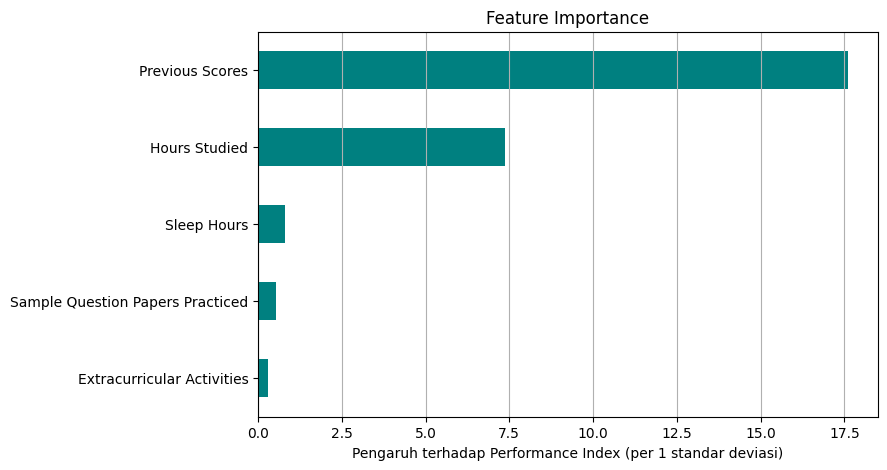

Previous Scores                     17.621046
Hours Studied                        7.373783
Sleep Hours                          0.802189
Sample Question Papers Practiced     0.540087
Extracurricular Activities           0.286924
dtype: float64


In [16]:
importance = pd.Series(model.coef_ * X_train.std().values, index=X.columns).abs().sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='teal')
plt.xlabel('Pengaruh terhadap Performance Index (per 1 standar deviasi)')
plt.title('Feature Importance')
plt.grid(True, axis='x')
plt.show()

print(importance.sort_values(ascending=False))

**Interpretasi:** Setelah perbedaan skala diperhitungkan, **Previous Scores** menjadi fitur yang paling berpengaruh dengan nilai sekitar 17,6 poin, jauh di atas fitur lainnya. Posisi kedua ditempati **Hours Studied** dengan sekitar 7,4 poin. Tiga fitur sisanya, yaitu Sleep Hours (±0,8), Sample Question Papers Practiced (±0,5), dan Extracurricular Activities (±0,3), memiliki pengaruh yang sangat kecil.

Urutan ini sama persis dengan hasil correlation matrix pada bagian 5.2, sehingga dapat disimpulkan bahwa performa siswa terutama ditentukan oleh nilai sebelumnya dan jumlah jam belajar.

## 11. Evaluasi Model
Setelah model terbentuk, kemampuannya perlu diukur menggunakan data uji, yaitu data yang sama sekali tidak digunakan saat pelatihan. Evaluasi dilakukan menggunakan empat metrik berikut:

| Metrik | Arti | Nilai ideal |
|---|---|---|
| **R² (Koefisien Determinasi)** | Persentase variasi target yang dapat dijelaskan model | Mendekati 1 |
| **MSE (Mean Squared Error)** | Rata-rata kuadrat selisih nilai aktual dan prediksi | Mendekati 0 |
| **RMSE (Root Mean Squared Error)** | Akar dari MSE, satuannya sama dengan target | Mendekati 0 |
| **MAE (Mean Absolute Error)** | Rata-rata selisih absolut nilai aktual dan prediksi | Mendekati 0 |

### 11.1 R² dan MSE

In [17]:
# Melakukan prediksi
y_pred = model.predict(X_test)

# Menghitung evaluasi
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.4f}")

R² Score : 0.9884
MSE      : 4.3059


### 11.2 RMSE dan MAE
RMSE dan MAE ditambahkan karena lebih mudah diinterpretasi. Satuan kedua metrik ini sama dengan Performance Index, sehingga langsung menunjukkan berapa poin rata-rata prediksi model meleset dari nilai sebenarnya.

In [18]:
from sklearn.metrics import mean_absolute_error
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

RMSE : 2.0751
MAE  : 1.6470


**Interpretasi:**
- **R² = 0,9884:** model mampu menjelaskan 98,84% variasi Performance Index.
- **MSE = 4,31:** rata-rata kuadrat error prediksi.
- **RMSE = 2,08:** prediksi rata-rata meleset sekitar ±2 poin dari nilai sebenarnya.
- **MAE = 1,65:** rata-rata selisih absolut antara prediksi dan nilai aktual hanya 1,65 poin.

Untuk target dengan rentang 10–100, error sekitar 2 poin tergolong sangat kecil. Berdasarkan keempat metrik tersebut, model dapat dikategorikan **sangat baik** dalam memprediksi Performance Index.

### 11.3 Pengecekan Overfitting
Model dengan R² tinggi belum tentu baik jika ternyata hanya "menghafal" data latih. Kondisi ini disebut **overfitting**, dan biasanya ditandai dengan performa yang sangat tinggi pada data latih tetapi jauh lebih rendah pada data uji. Untuk memastikannya, R² pada data latih dibandingkan dengan R² pada data uji.

In [19]:
r2_train = model.score(X_train, y_train)
r2_test = r2_score(y_test, y_pred)

print(f"R² data latih : {r2_train:.4f}")
print(f"R² data uji   : {r2_test:.4f}")
print(f"Selisih       : {abs(r2_train - r2_test):.4f}")

R² data latih : 0.9887
R² data uji   : 0.9884
Selisih       : 0.0003


**Interpretasi:** R² pada data latih (0,9887) dan data uji (0,9884) hampir identik dengan selisih hanya 0,0003. Artinya, model bekerja sama baiknya pada data yang sudah pernah dilihat maupun data baru, sehingga **tidak terjadi overfitting**. Model benar-benar mempelajari pola umum, bukan sekadar menghafal data latih.

### 11.4 Cross-Validation
Hasil evaluasi di atas hanya berasal dari satu kali pembagian data. Untuk memastikan bahwa hasil tersebut bukan kebetulan, dilakukan **5-fold cross-validation**. Pada metode ini, data dibagi menjadi 5 bagian (*fold*), lalu model dilatih dan diuji sebanyak 5 kali dengan bagian yang berbeda sebagai data uji pada setiap putarannya. Jika nilai R² di setiap fold mirip, berarti performa model stabil.

In [20]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("R² tiap fold :", np.round(cv_scores, 4))
print(f"Rata-rata R² : {cv_scores.mean():.4f}")

R² tiap fold : [0.9888 0.9882 0.989  0.9891 0.9882]
Rata-rata R² : 0.9887


**Interpretasi:** Nilai R² pada kelima fold berada di rentang **0,9882–0,9891** dengan rata-rata **0,9887**. Nilai ini sangat konsisten antar fold dan hampir sama dengan R² pada data uji (0,9884). Hal ini menunjukkan bahwa performa model **stabil** dan tidak bergantung pada satu cara pembagian data tertentu.

### 11.5 Perbandingan dengan Model Lain
Untuk membuktikan bahwa Linear Regression memang pilihan yang tepat, performanya dibandingkan dengan tiga model regresi lain menggunakan data latih dan data uji yang sama:
- **Ridge Regression:** Linear Regression yang ditambah regularisasi untuk mengurangi risiko overfitting.
- **Decision Tree:** model berbasis pohon keputusan yang mampu menangkap pola non-linear.
- **Random Forest:** gabungan dari banyak Decision Tree yang hasilnya dirata-rata.

In [21]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

hasil = []
for nama, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    hasil.append({
        'Model': nama,
        'R²': r2_score(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

pd.DataFrame(hasil).sort_values('R²', ascending=False)

,Model,R²,RMSE
0,Linear Regression,0.988430,2.075066
1,Ridge Regression,0.988430,2.075077
3,Random Forest,0.984875,2.372552
2,Decision Tree,0.975258,3.034488


**Interpretasi:** Linear Regression memperoleh R² tertinggi (0,9884) dan RMSE terendah (2,075), dengan hasil yang hampir identik dengan Ridge Regression. Sebaliknya, model yang lebih kompleks justru menghasilkan performa yang lebih rendah, yaitu Random Forest dengan R² 0,9849 (RMSE 2,37) dan Decision Tree dengan R² 0,9753 (RMSE 3,03).

Hasil ini menunjukkan bahwa hubungan antara fitur dan Performance Index memang bersifat **linear**, sehingga model yang dirancang untuk menangkap pola non-linear tidak memberikan keuntungan tambahan. Linear Regression menjadi model yang paling sesuai karena paling akurat sekaligus paling sederhana dan mudah diinterpretasi.

## 12. Visualisasi Performa Model
Selain menggunakan angka, performa model juga dianalisis secara visual. Visualisasi ini sekaligus digunakan untuk mengecek apakah asumsi-asumsi Linear Regression terpenuhi, melalui analisis **residual**, yaitu selisih antara nilai aktual dan nilai prediksi.

### 12.1 Aktual vs Prediksi
Grafik ini membandingkan nilai aktual dengan nilai prediksi pada data uji. Garis merah putus-putus merupakan garis ideal, yaitu kondisi ketika nilai prediksi sama persis dengan nilai aktual. Semakin dekat titik-titik dengan garis tersebut, semakin akurat prediksinya.

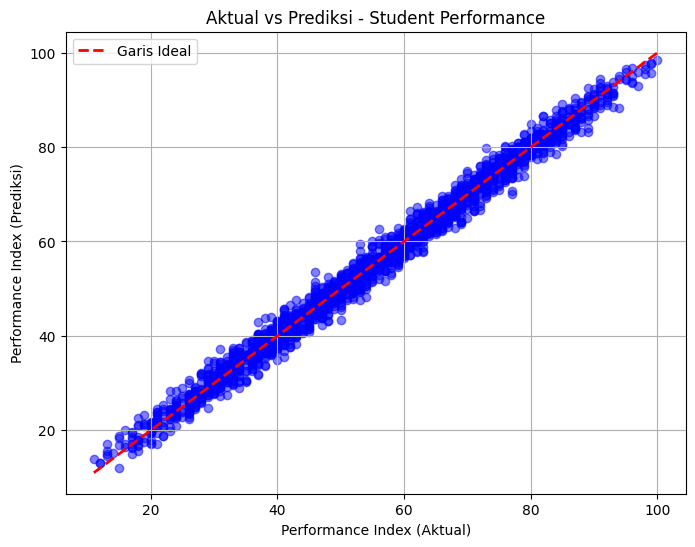

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Garis Ideal')
plt.xlabel('Performance Index (Aktual)')
plt.ylabel('Performance Index (Prediksi)')
plt.title('Aktual vs Prediksi - Student Performance')
plt.legend()
plt.grid(True)
plt.show()

**Interpretasi:** Titik-titik data membentuk pola yang rapat di sepanjang garis ideal, mulai dari nilai rendah hingga nilai tinggi. Hal ini menunjukkan bahwa model mampu memprediksi dengan akurat dan konsisten di seluruh rentang Performance Index, tidak hanya pada rentang nilai tertentu.

### 12.2 Distribusi Residual
Salah satu asumsi Linear Regression adalah residual berdistribusi normal dan terpusat di angka 0. Asumsi ini dicek menggunakan histogram residual.

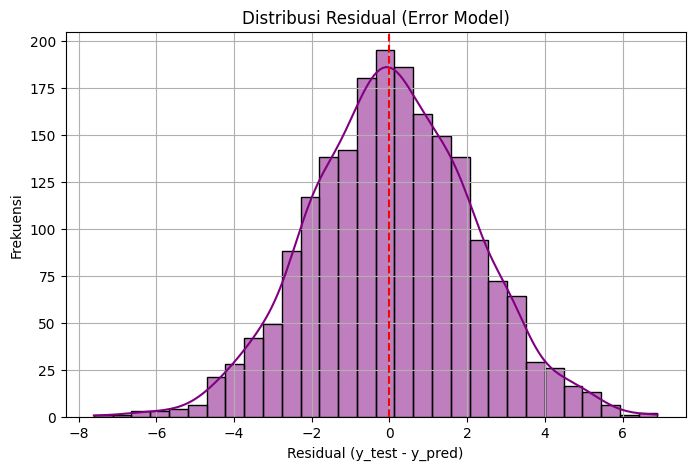

In [23]:
# Plot residual (error)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (y_test - y_pred)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Residual (Error Model)')
plt.grid(True)
plt.show()

**Interpretasi:** Residual membentuk kurva menyerupai lonceng (distribusi normal) dan terpusat di sekitar 0. Sekitar 94% prediksi memiliki error dalam rentang ±4 poin, dan hanya sedikit yang meleset lebih jauh. Artinya, model tidak cenderung memprediksi terlalu tinggi maupun terlalu rendah, sehingga **asumsi normalitas residual terpenuhi**.

### 12.3 Residual vs Prediksi
Plot ini digunakan untuk mengecek dua asumsi Linear Regression lainnya:
- **Linearitas:** residual tidak membentuk pola tertentu, misalnya melengkung.
- **Homoskedastisitas:** lebar sebaran residual relatif sama di seluruh nilai prediksi, tidak melebar atau menyempit seperti corong.

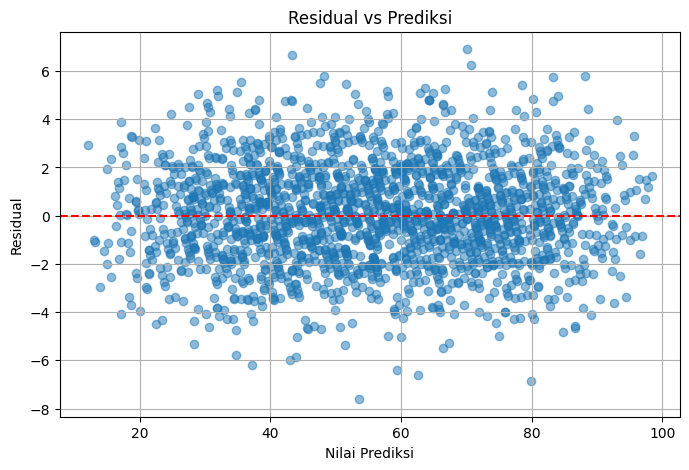

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')
plt.title('Residual vs Prediksi')
plt.grid(True)
plt.show()

**Interpretasi:** Residual tersebar secara acak di sekitar garis 0 tanpa membentuk pola tertentu, dan lebar sebarannya relatif sama dari nilai prediksi rendah hingga tinggi. Dengan demikian, **asumsi linearitas dan homoskedastisitas terpenuhi**. Bersama dengan hasil pada bagian 12.2, hal ini memperkuat bahwa Linear Regression memang cocok digunakan untuk dataset ini.

## 13. Prediksi Data Baru
Setelah terbukti akurat dan memenuhi asumsi, model dapat digunakan untuk tujuan utamanya, yaitu memprediksi Performance Index siswa baru yang tidak terdapat di dalam dataset. Sebagai contoh, digunakan data seorang siswa yang belajar selama **7 jam**, memiliki nilai sebelumnya **85**, **ikut** ekstrakurikuler, tidur selama **7 jam**, dan mengerjakan **4** latihan soal.

In [25]:
# Contoh input data siswa baru:
# [Hours Studied, Previous Scores, Extracurricular Activities (1/0), Sleep Hours, Sample Question Papers Practiced]
siswa_baru = pd.DataFrame([{
    'Hours Studied': 7,
    'Previous Scores': 85,
    'Extracurricular Activities': 1,
    'Sleep Hours': 7,
    'Sample Question Papers Practiced': 4
}])

prediksi_nilai = model.predict(siswa_baru)
print(f"Prediksi Performance Index Siswa Baru: {prediksi_nilai[0]:.2f}")

Prediksi Performance Index Siswa Baru: 77.18


**Interpretasi:** Siswa tersebut diprediksi memiliki Performance Index sebesar **77,18**. Hasil ini dapat dicek secara manual menggunakan persamaan model:

−33,98 + 2,851(7) + 1,018(85) + 0,574(1) + 0,472(7) + 0,189(4) ≈ **77,18**

Dengan RMSE sekitar ±2 poin, nilai Performance Index sebenarnya dari siswa ini kemungkinan besar berada di kisaran 75–79.

## 14. Kesimpulan
Berdasarkan hasil analisis, model **Multiple Linear Regression** berhasil memprediksi Student Performance Index dengan **sangat baik**. Pada data uji, model memperoleh **R² sebesar 0,9884**, yang berarti **98,84%** variasi Performance Index dapat dijelaskan oleh model, dengan rata-rata kesalahan prediksi hanya sekitar **2 poin** (**RMSE = 2,08** dan **MAE = 1,65**). Model juga terbukti **tidak mengalami overfitting**, karena nilai R² pada data latih (**0,9887**) dan data uji (**0,9884**) hampir sama, serta hasil **5-fold cross-validation** stabil dengan rata-rata R² sebesar **0,9887**.

Dari sisi faktor yang memengaruhi, **Previous Scores** merupakan fitur yang **paling berpengaruh** terhadap Performance Index, diikuti oleh **Hours Studied**. Sementara itu, Sleep Hours, Sample Question Papers Practiced, dan Extracurricular Activities tetap berpengaruh positif, tetapi kontribusinya **sangat kecil**. Hasil analisis residual menunjukkan bahwa asumsi **normalitas**, **linearitas**, dan **homoskedastisitas** terpenuhi, dan perbandingan dengan Ridge Regression, Decision Tree, serta Random Forest menunjukkan bahwa **Linear Regression memberikan performa terbaik** sekaligus paling mudah diinterpretasi. Sebagai penerapan, seorang siswa dengan data contoh diprediksi memiliki Performance Index sebesar **77,18**.

## 15. Keterbatasan dan Saran
**Keterbatasan:**
- Model hanya menggunakan 5 fitur, sehingga faktor lain yang juga dapat memengaruhi performa siswa, seperti motivasi, kondisi ekonomi, kualitas pengajar, dan lingkungan belajar, belum diperhitungkan.
- Dataset yang digunakan merupakan dataset publik dengan pola yang sangat teratur (sebaran fitur merata dan hubungan sangat linear), sehingga performa model pada data siswa nyata kemungkinan tidak setinggi hasil ini.
- Model hanya dapat diandalkan untuk data yang berada dalam rentang data latih (misalnya jam belajar 1–9 jam dan nilai sebelumnya 40–99). Prediksi di luar rentang tersebut belum tentu akurat.

**Saran:**
- Menambahkan fitur lain yang relevan agar model dapat menjelaskan performa siswa secara lebih menyeluruh.
- Menguji model menggunakan data siswa nyata, misalnya data dari institusi pendidikan tertentu, untuk melihat kemampuan generalisasinya.
- Jika pada data lain ditemukan pola non-linear, dapat dicoba model seperti Polynomial Regression atau Random Forest sebagai pembanding.